## ***MNIST***

***Get data***

*70000 image of handwritten digts*

In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)

*Here we get the data (X, y) as Numpy array `(as_frame=False)`. Cause MNIST dataset is image & DataFrame isn't ideal for that*

In [2]:
x, y = mnist.data, mnist.target
x

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [3]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [4]:
print(x.shape, y.shape)

(70000, 784) (70000,)


***There are `70,000 images` of `28x28 pixels`, & each pixel is represented by a feature, so there are 784 features. Feature simply represent pixel's intencity, from 0(white) to 255(black). The target is the digit represented by the image***

***We need to grab an instance's feature vector`(784)`, reshape it to `28x28` array, display it using `Matplotlinb's imshow()` func, use `cmap="binary"` to get a grayscale color map***

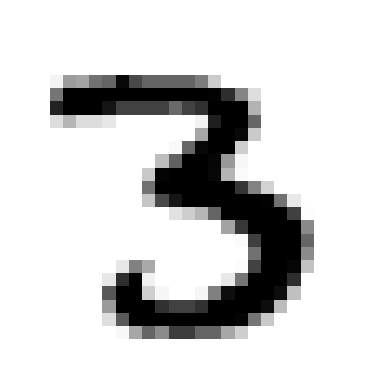

'3'

In [5]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

data = x[12]
plot_digit(data)
plt.show()

# label of the image
y[12]

*We should always split the data into train test set before inspecting the data  closely,*
- **MNIST** *data is already split into (60,000 & 10,000) set*
- *Training set already shuffled means `cross-validation` folds will be similar*

*some learning algorithms are sensitive to the order of the training instances, and they perform poorly if they get many similar instances in a row. Shuffling the dataset ensures that this won’t happen*

In [6]:
x_train, x_test, y_train, y_test = x[:60000], x[60000:], y[:60000], y[60000:]

---

## ***Training a binary classifier***

***To simplify theproblem only trying to identify 1 digit `5`***
- *Create target vector for `classification`*

In [7]:
y_train_5 = (y_train == '5') # True for all 5 & False for all other digits
y_test_5 = (y_test == '5')

*Now let's train it*

In [8]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(x_train, y_train_5)

SGDClassifier(random_state=42)

In [9]:
sgd_clf.predict(x[11].reshape(1, -1))

array([ True])

In [10]:
y[11]

'5'

***So the classifier guessed it right, Now let's evaluate the model's performance***

---

## ***Performance Measure***

### ***Measure accuracy using Cross-Validation***

In [11]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, x_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

*More than `95%`, to make sure let's classify with a `dummy classifier` that just clussify every image with most frequent class*

In [12]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier()
dummy_clf.fit(x_train, y_train_5)

print(any(dummy_clf.predict(x_train))) # Print false [no 5 detected]

False


In [13]:
cross_val_score(dummy_clf, x_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

*90% accuracy, cause only `10% image` is of `5`, So if I always guess an image is `5` I will be right `90%` of the time*

*This is why `accuracy` is not prefered performance measure for `classifier`, especially when the data is skewed*

***Better way to measure performance of a classifier is to look at the `Confusion matrix`***

### ***Confusion Matrices***

*The general idea  is to count the number of times instances of class A is classified as class B for all A/B pair*

*For this we need predictions first, but as we don't want to touch the `test_set` will use the `cross_val_predict()` function, Which perform `k-fold cross-validation` but instead of returning evaluation score return predictions made on each test fold*

*We get a `clean prediction(out of sample)` for each instance on training set `{means the model make prediction on data that is not seen while training}`*

In [14]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, x_train, y_train_5, cv=3)

In [15]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]], dtype=int64)

***TN*** (True Negative){*correctly clasified as non-5*} - `53892`, ***FP*** (False Positive/ Type I error){*Wrongly classified as 5*} - `687`, \
***FN*** (False Negative/ Type II error){*Wrongly classified as non 5*} - `1891`, ***TP*** (True Positive){*Correctly classified as 5*} - `3530` 

*A perfect classifier will have onlt TP & TN , so the CM would have non-zero values only on it's main diagonal*

In [16]:
y_train_perfect_predictions = y_train_5 # pretend we reached perfection (like with a hypothetical classifier)
cm_perfect = confusion_matrix(y_train_5, y_train_perfect_predictions)
cm_perfect

array([[54579,     0],
       [    0,  5421]], dtype=int64)

***A more concise metric is `accuracy of the positive prediction` (`precision` of the classifier)*** ~ *`How many instances predicted as positive are actually positive`*
$$Precision = \frac{TP}{TP + FP}$$
*Sensitivity or true positive rate(TPR) ~ `Ratio of positive instances that are correctly detected by the classifier`*
$$Recall = \frac{TP}{TP + FN}$$

### ***Precision & Recall***

In [17]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [18]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

*Now when we look at the accuracy of 5-detector it oesn't look that good*
- Now when it claim the image is `5` it's `83.7%` of the time right
- Moreover detect only `65%` of the 5s 

***Now we combine the 2 metrices & get $F_1 score$ when we need a single metrices to compare 2 classifier, The $F_1 score$ is the `harmonic mean` of recall & precision***
- *Where regular mean give same value to all values the `harmonic mean` give more weight to the `lower values` as a result the classifier won't get a high score if both the recall & precision score are high* 
$$F_{1} Score = \frac{1}{\frac{1}{precision}+\frac{1}{recall}} = 2 * \frac{precision * recall}{precision + recall} = \frac{TP}{TP + \frac{FN + FP}{2}}$$

In [19]:
from sklearn.metrics import f1_score

f1score = f1_score(y_train_5, y_train_pred)
f1score

0.7325171197343847

*F1 score favour the classifiers that have `same recall & precision`, but this isn't what we want in some we really care about recall & in few case we care about precision*

*Like in medical diagnosis need `high recall` to avoid missing anything important*

*Unfortunately we can't have these both together* 
- Increasing precision & decreasing recall  & vice versa , this is called `precision/recall trade-off`

### ***Precision /Recall trade-off***

*To understand this see how `SGDCllasifier` works, for each instance it computes a score based on `decision function`, If that score is higher than a `threshold` it assign the instance to positive class otherwise assign to the negative class*

In [20]:
y_score = sgd_clf.decision_function(x[11].reshape(1, -1))
y_score

array([4742.52813158])

In [21]:
threshold = 30000
y_some_digit_pred = (y_score > threshold)
y_some_digit_pred

array([False])

*So when the threshold is `0` the code return the same result as `predict()` method*

*Now increase the `threshold` to `30000` ~> return `false`, this confirm that raising the threshold decreases recall* `[the image is actually 5]`

In [22]:
y[11]

'5'

***How do we decide which threshold to choose ~ use `cross_val_predict()`, specify instead of `prediction` return `decision_score`*** 

In [23]:
y_score = cross_val_predict(sgd_clf, x_train, y_train_5, cv=3, method="decision_function")

***use `precision_recall_curve()` to compute precision & recall for all possible thresholds*** 

*the function adds a last precision of 1 and a last recall of 0, corresponding to an infinite threshold*

In [24]:
from sklearn.metrics import precision_recall_curve
precisions, recalls,thresholds = precision_recall_curve(y_train_5, y_score)

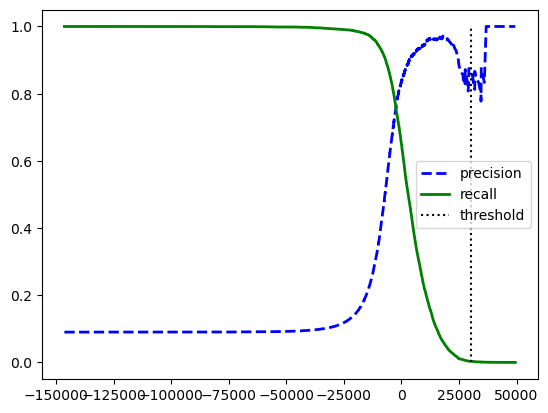

In [25]:
plt.plot(thresholds, precisions[:-1], "b--", label="precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")
plt.legend()
plt.show()

*At that threshold(30000) precision is near `90%` & recall is near `50%`*

*Another way to select a good precision/recall is to plot precision against recall*

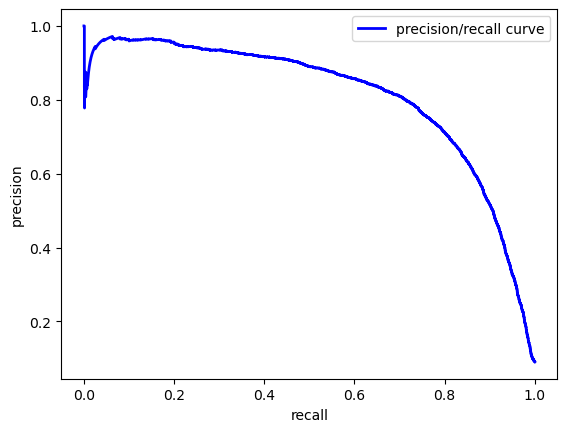

In [26]:
plt.plot(recalls, precisions, "b-", linewidth=2, label="precision/recall curve")
plt.xlabel("recall")
plt.ylabel("precision")
plt.legend()
plt.show()

*Can see the precision fall around `80%` recall, so we want to select a precision/recall treadoff before that drop around `60%` recall, but that depend on the project*

*Let's say aiming for `90%` precision getting it from the graph won't be precise, so we'll use `argmax()` method, this return the first index of the max value(`First true value`)*

In [27]:
import numpy as np
idx_for_90_precision = np.argmax(precisions >= 0.90)
threshold_90_precision = thresholds[idx_for_90_precision]
threshold_90_precision

3370.0194991439557

In [28]:
y_train_pred_90 = (y_score >= threshold_90_precision)

In [29]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [30]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

***A higher precision classifier is not useful if the recall is very low***

***There are more class to easily adjust the decision threshold***
- **FixedThresholdClassifier ~**  ***aahh!*** `Binary classifier`

- **TunedThresholdClassifierCV ~** `use k-fold cross validation to automatically find the optimal threshold for a given metric, by default it tries to maximize the model's balanced accuracy(average of each classe's recall)` 

### ***ROC curve***

***`Receiver Operating Characteristic` another tool used with binary classifiers***

*It's a TPR vs TNR graph*
$$TPR = \frac{TP}{TP + FN}, TNR = \frac{FP}{TP + FP}$$

***ahhhhhh!***

In [31]:
from sklearn.metrics import roc_curve
fpr,tpr, thresholds = roc_curve(y_train_5, y_score)

[]

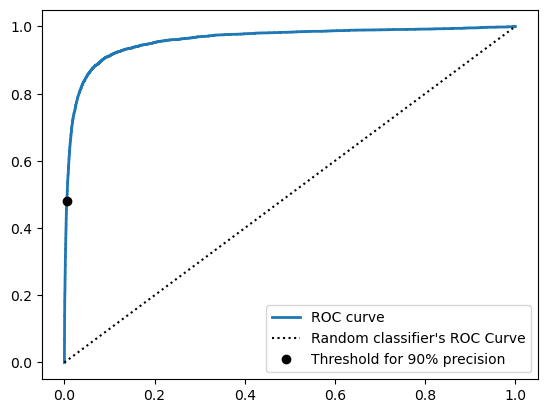

In [32]:
idx_for_threshold_at_90 = (thresholds <= threshold_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], "k:", label="Random classifier's ROC Curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")
plt.legend()
plt.plot()

***Comparing the classifiers is to measure the `Area Under the Curve` , A perfect classifier will have `AUC` of `1`, whereas a purely random classifier will have `ROC AUC` equal to `0.5`*** 

In [33]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_score)

0.9604938554008616

***Let's create a `RandomForestClassifier` & see the comparison of `PRC & F1 score` with `SGDClassifier`***

In [34]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)

***`precision_recall_curve()` func expect labels & score for each instance, so we need to train `RFC` & make it assign a score toeach instance, but `RandomFOrestClassifier` don't have `decision_function` but have `predict_proba()` that peovide estimated class probability & we can use the prob of the +class as `score` so we can call `cross_val_predict()` to train `RFC` using `cross validation` & make it predict class prob for every image***

In [35]:
y_probas_forest = cross_val_predict(forest_clf, x_train, y_train_5, cv=3, method="predict_proba")
y_probas_forest[:5]

array([[0.11, 0.89],
       [0.99, 0.01],
       [0.96, 0.04],
       [1.  , 0.  ],
       [0.99, 0.01]])

*So the model predict the 1st image `positive` with `89%` probability & 2nd image `negative` with `99%` probability `{as each image is either pos or neg the estimated prob in each row is 100%}`*

***The 2nd column contain the score for positive class, so pass them to `precision_recall_curve()` func***

In [36]:
y_score_forest = y_probas_forest[:,1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_train_5, y_score_forest)

*Now compare the PRC of both algo*

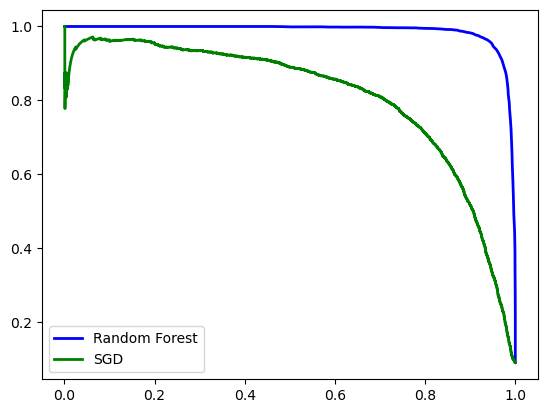

In [37]:
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest")
plt.plot(recalls, precisions, "g-", linewidth=2, label="SGD")
plt.legend()
plt.show()

***`Random Forest Classifier Curve` looks better than the `SGD curve` as it comes closer to the top right corner, also the `F1 score` & `AUC` is better***

In [38]:
y_train_pred_forest = y_probas_forest[:, 1]>=0.5 # positive probability >= 50%
f1_score(y_train_5, y_train_pred_forest)

0.9274509803921569

In [39]:
roc_auc_score(y_train_5, y_train_pred_forest)

0.9358174809192218

In [40]:
# precision & recall score

precision = precision_score(y_train_5, y_train_pred_forest)
recall = recall_score(y_train_5, y_train_pred_forest)
print(precision, recall)

0.9897468089558485 0.8725327430363402


## ***Multiclass Classification***

***Multinomial classifier distinguish b/w more than two class***

*Classifiers capable of multinomial classification are*
- Logistic Regression
- RandomForestClassification
- GaussianNB

*Others are binary classsification*
- SGDClassification
- SVC

- ***Here the system can classify image into 10 different class, we get  `decision score` from each classifier & select one with highest score, this called `0ne-versus-the-rest(OvR)` strategy or `One-versus-all(OvA)`***
- ***Another way is `binary classifier` for each pair of digit, like (0, 1),(0, 2),(1,2),... this is called `One-versus-One` strategy. If there are `N` digits I need to train `N *(N-1) /2` classifiers***

- *So for MNIST need to train `10 * (10 - 1) / 2 = 45` binary classifiers*

***For algos like `SVM Classifier` scale poorly with the size of training set, So OVO is prefered as this faster to train manclassifier on large training set than train few class on large set***

In [41]:
from sklearn.svm import SVC
svm_clf = SVC(random_state=42)
svm_clf.fit(x_train[:2000], y_train[:2000]) # not y_train_5

SVC(random_state=42)

In [42]:
y_train[12]

'3'

In [43]:
svm_clf.predict(x[12].reshape(1, -1))

array(['3'], dtype=object)

***So there are 45 pairwise classifier, but `decision_function()` return 10 values (one per class: 0-9)*** 

*The score work like ~*\
Take one class, say digit 5\
It participates in 9 duels \
`5 vs 0, 5 vs 1, 5 vs 2 ... 5 vs 9`

For each duel 
- If classifier say 5 wins -> +1
- If it not -> 0 

*So base score = no of wins*

***+ Small tweak***
*Each classifier also output a confident score (`distance from decision boundary in SVM`)*\
That add a tiny adjustment ~ `Score = wins + small margin adjustment (± up to ~0.33)`

*This help ~* 
- break ties
- rank classes more smoothly

*Digit 3 has highest score `9.3` means most win & strong confident , digit 1 score `-0.28` means most loss & classifier has no confident*

In [44]:
digit_scores = svm_clf.decision_function(x[12].reshape(1, -1))
digit_scores

array([[ 3.75239626, -0.2813685 ,  5.90560809,  9.31176678,  2.7376656 ,
         8.28633016,  0.7176527 ,  1.72687192,  7.24809605,  4.83406056]])

In [45]:
class_id = digit_scores.argmax()
class_id

3

*When a classifier is trainded it stores the list of targets in it's `classes_` attribute orderes by value, in MNIST the index match the class, but in other case it won't be same so must check the `classes_` atr*

In [46]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [47]:
svm_clf.classes_[class_id]

'3'

*OneVsRestClassifier or OneVsOneClassifier*

In [48]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(x_train[:2000], y_train[:2000])

OneVsRestClassifier(estimator=SVC(random_state=42))

In [49]:
ovr_clf.predict(x[12].reshape(1, -1))

array(['3'], dtype='<U1')

In [50]:
len(ovr_clf.estimators_) # no of trained classifier

10

*SGDClassifier*

In [51]:
y_train[21]

'0'

In [52]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(x_train[:2000], y_train[:2000]) 
sgd_clf.predict(x_train[21].reshape(1, -1))

array(['0'], dtype='<U1')

In [53]:
sgd_clf.decision_function(x_train[21].reshape(1, -1)).round()

array([[ 1552211., -2322022., -2845534.,  -955736., -3504331.,  -968616.,
        -4734441., -2509421., -1940836., -1081109.]])

***Can see the classifier isn't very confident about it's prediction, but we'll evaluate on many image. Can use `cross_val_score()` to evaluate the model***

In [54]:
cross_val_score(sgd_clf, x_train, y_train, cv=3, scoring='accuracy')

array([0.87365, 0.85835, 0.8689 ])

*Over `85%` in all test folds, but scaling the input can increase accuracy to `89.1%`*

In [55]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train.astype("float64"))
cross_val_score(sgd_clf, x_train_scaled, y_train, cv=3, scoring='accuracy')

array([0.8983, 0.891 , 0.9018])

## ***Error Analysis***

***Let's say I have found a promising model & want improve it, so I'll analyze the error it makes***
- *1st Look at the confusion matrix ~* use `ConfusionMatrixDisplay.from_prediction()` function

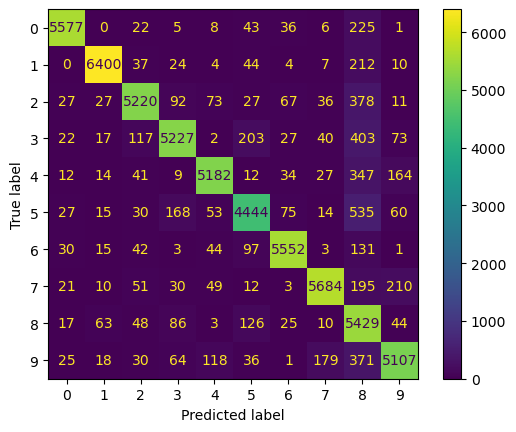

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = cross_val_predict(sgd_clf, x_train_scaled, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

***Can see the diagonal 5 is bit darker than other diagonals mean model did more error on 5s or there are fewer image of 5 than other digits, that's why need to normalize the `confusion matrix` by dividing each value with numv=ber of image of corresponding class***

*Just set `normalize='true'` & `values_format='.0%'` for no decimal*

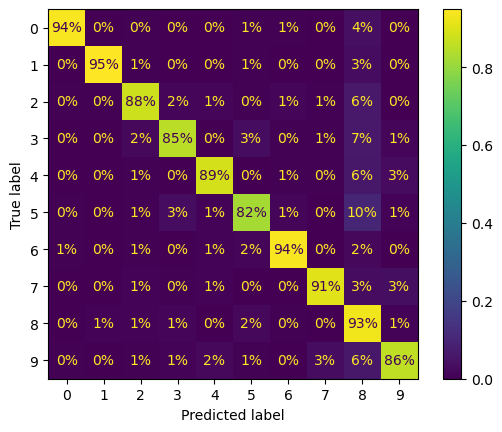

In [57]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize="true", values_format=".0%")
plt.show()

***If I want to make the errors standout I can add `0` weight on the correct predictions***

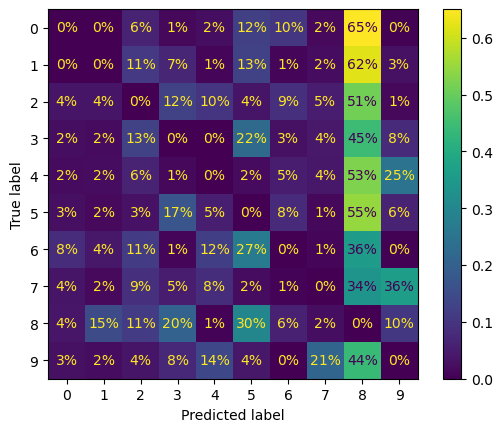

In [59]:
sample_weight = (y_train_pred != y_train) 

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, sample_weight = sample_weight, normalize="true", values_format=".0%")

plt.show()

*This is a error only confusion matrix, can see the column of `8` is really bright means many images got misclassified as `8s`*

*In this `CM` in row #7 col #9 `36%` doesn't mean all `7s` were misclassified as `9` but `36%` of the error the model made on image `7` were misclassified as `9`*

*So the plot tells us to reduce the false `8s`*

*For this we*
- *can add more data that look like `8` but actually not*
- *or engineer feature that can help identify `8`*

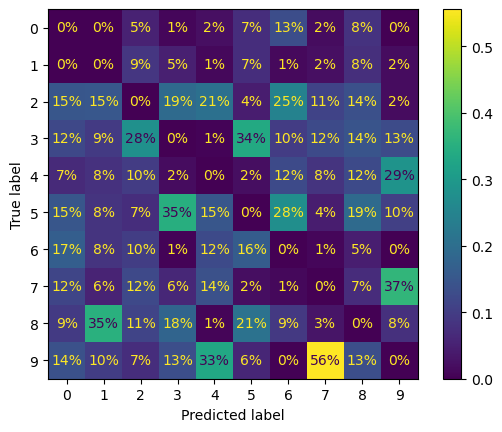

In [ ]:
# Normalized CM by column
sample_weight = (y_train_pred != y_train) 

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, sample_weight = sample_weight, normalize="pred", values_format=".0%")

plt.show()

***Analyzing individual CM can also help about what the classifier doing wrong***

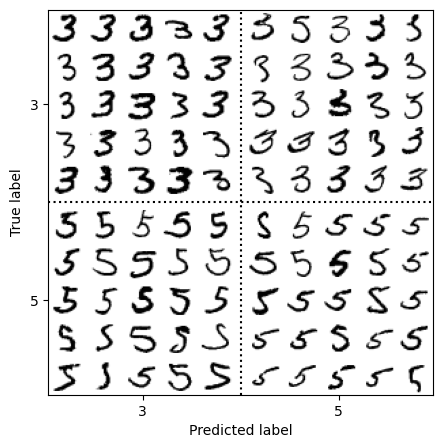

In [61]:
cl_a, cl_b = '3','5'

x_aa = x_train[(y_train == cl_a) & (y_train_pred == cl_a)]
x_ab = x_train[(y_train == cl_a) & (y_train_pred == cl_b)]
x_ba = x_train[(y_train == cl_b) & (y_train_pred == cl_a)]
x_bb = x_train[(y_train == cl_b) & (y_train_pred == cl_b)]

# =====
size = 5
pad = 0.2
plt.figure(figsize=(size, size))
for images, (label_col, label_row) in [(x_ba, (0, 0)), (x_bb, (1, 0)),
                                       (x_aa, (0, 1)), (x_ab, (1, 1))]:
    for idx, image_data in enumerate(images[:size*size]):
        x = idx % size + label_col * (size + pad)
        y = idx // size + label_row * (size + pad)
        plt.imshow(image_data.reshape(28, 28), cmap="binary",
                   extent=(x, x + 1, y, y + 1))
plt.xticks([size / 2, size + pad + size / 2], [str(cl_a), str(cl_b)])
plt.yticks([size / 2, size + pad + size / 2], [str(cl_b), str(cl_a)])
plt.plot([size + pad / 2, size + pad / 2], [0, 2 * size + pad], "k:")
plt.plot([0, 2 * size + pad], [size + pad / 2, size + pad / 2], "k:")
plt.axis([0, 2 * size + pad, 0, 2 * size + pad])
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.show()

***Can see all the misclassified images are badly written, as the `SGDClassifier` we is a linear model gave weight per class to each pixel when it seems a new image just sum all the weighted pixels to get a score for each classes, since 3 & 5 differ by few pixel model will easily confuse them***

***Here we need `data augmentation` to tackle this confusion***

## ***Multilabel Classification***

*Ex: Let's say model is train to recognize 3 faces, if there is an image of 2 person the model should recognize `[1st: True, 2nd: False, 3rd: True]` means multiple binary tag in output*

In [63]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8')%2==1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(x_train, y_multilabel)

KNeighborsClassifier()

***This create a multilabel array containing 2 target `>= 7 & odd/even`***

***use `KNeighborsClassifier()` instance which support `multilabel classifier`, train with multiple tarfgets array***

In [66]:
y_train[0]

'5'

In [65]:
knn_clf.predict(x_train[0].reshape(1, -1))

array([[False,  True]])

***Another way is to measure individual `F1 score (or other binary classifier)` of each label & average the score***
- *This approach assume all labels are equally important*

In [68]:
y_train_knn_pred = cross_val_predict(knn_clf, x_train, y_multilabel, cv=3)

f1_score(y_multilabel, y_train_knn_pred, average='macro')

0.9764102655606048

- *This not may be the case for all let's say one image is large in number so give more weight to that or just give each label a weight equal to it's support*
- *For this set `average="weighted"` while calling `f1_score`*

In [69]:
f1_score(y_multilabel, y_train_knn_pred, average='weighted')

0.9778357403921755

***What if use a classifier that doesn't support `multilabel classifier`***
- *One approach is to train one model for each label, but this strategy may have hard time capturing dependencies b/w labels*
- *Ex: large no (7,8,9) is twice more likely to be odd than even, but the classifier `odd` doesn't know what classifier `even` predicted*

***To solve this models can be organized in chain, when a model predict it use the `input feature` & all the prediction of the models comes before in the chain***
    
```
Model 1 → predicts A  
Model 2 → uses A → predicts B  
Model 3 → uses A + B → predicts C
```

***But problem in this is***
- *During training , by default*
    ```
    Model 2 gets the TRUE label of A  
    Model 3 gets TRUE labels of A and B
    ```
- *Means*
    - *Model sees perfect previous labels*
    - *But during prediction they only get `predicted(imperfect)` labels*
- *So model perform worse in reality than expected*
- ***We use `CV`, Instead of giving true labels:***
    - Split training data into folds
    - Train model on some folds
    - Predict on unseen fold
    - Collect those predictions

    *Now these are not true label, but closer to real world prediction*
- 

In [70]:
from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), cv=3,random_state=42)
chain_clf.fit(x_train[:2000], y_multilabel[:2000])

ClassifierChain(base_estimator=SVC(), cv=3, random_state=42)

In [71]:
chain_clf.predict(x_train[0].reshape(1, -1))

array([[0., 1.]])

## ***Multioutput Classification***

***Generalization of `multilabel classification` where each label can be multiclass (`it can have more than 2 possible value`)***

*For this build a noise removing system*
- *It will take i/p a noisy image & o/p an clean image representing the array of intensities*
- *The classifier' so/p is multilabel (`one label for each pixel`) & each label has multiple value (`from 0 to 255`)*

*Thus this is an example of `multioutput-multiclass classification`*

In [86]:
# create train/test set adding noise to their intensities
rng = np.random.default_rng(seed=42)
noise_train = rng.integers(0, 100, (len(x_train), 784))
x_train_mod = x_train + noise_train
noise_test = rng.integers(0, 100, (len(x_test), 784))
x_test_mod = x_test + noise_test
y_train_mod = x_train
y_test_mod = x_test

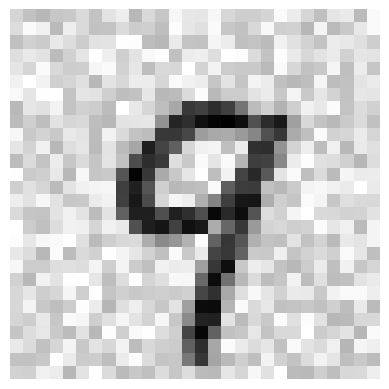

In [87]:
plot_digit(x_test_mod[12])

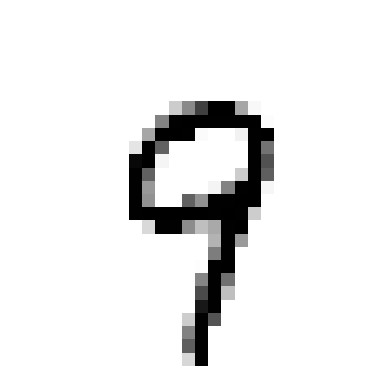

In [89]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(x_train_mod, y_train_mod)
clean_digit=knn_clf.predict([x_test_mod[12]])
plot_digit(clean_digit)
plt.show()

***This concludes our tour of classification. You now know how to select good metrics for classification tasks, pick the appropriate precision/recall trade-off, compare classifiers, and more generally build good classification systems for a variety of tasks***